# Context CD axis

This notebook builds a coding-direction (CD) axis from **high right-choice-probability** vs **high left-choice-probability** trials, using the sliding-window choice-probability trial types now produced by `generate_behavior_summary`.

Idea: the per-trial sliding-window P(right) reflects the animal's recent choice *bias* â€” i.e. the running context â€” rather than the action on the current trial. A CD axis fit on `right_choice_probability_bigger_{thr}` vs `left_choice_probability_bigger_{thr}` therefore captures **context encoding**, and can be compared with the standard choice-CD (right_choice vs left_choice on the current trial) to dissociate context vs choice encoding.

Trial-type columns expected in the behavior CSV (added in `behavior_utils.generate_behavior_summary`):

- `right_choice_probability_bigger_{thr}_windowsize_{N}_trials` â†’ trials whose sliding P(right) > thr
- `left_choice_probability_bigger_{thr}_windowsize_{N}_trials`  â†’ trials whose sliding P(left)  > thr  (equivalently P(right) < 1-thr)

In [5]:
# =============================================================================
# 1. ENVIRONMENT SETUP & MODULE IMPORTS
# =============================================================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"âœ… Analysis modules loaded from: {MODULE_PATH}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
âœ… Analysis modules loaded from: /root/capsule/src/aind_dft_ephys_analysis


In [6]:
# ALM recordings â€” sessions of interest
sessions = [
    "ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38",
    "ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35",
    "ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43",
    "ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45",
    "ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51",
    "ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13",
]

## Configure the context trial types

Choose the sliding-window threshold and window size that define "high P(right)" and "high P(left)" contexts. These must match entries produced by `generate_behavior_summary` (default windows: 5,10,15,20,30; default thresholds: 0.5,0.6,0.7,0.8,0.9).

In [25]:
# Context defining parameters
cp_threshold   = 0.8    # high-P(side) cutoff (strict >)
cp_windowsize  = 10     # sliding window length (responded trials only)

context_right = f"right_choice_probability_bigger_{cp_threshold}_windowsize_{cp_windowsize}_trials"
context_left  = f"left_choice_probability_bigger_{cp_threshold}_windowsize_{cp_windowsize}_trials"
context_trial_types = (context_right, context_left)

print("A (right-context):", context_right)
print("B (left-context) :", context_left)

A (right-context): right_choice_probability_bigger_0.8_windowsize_10_trials
B (left-context) : left_choice_probability_bigger_0.8_windowsize_10_trials


In [26]:
# =============================================================================
# Build CONTEXT-CD zarrs (high P(right) vs high P(left) trials)
# =============================================================================
from pathlib import Path
from ephys_dimension_reduction_CD_pipeline import build_cd_dataset

psth_root     = Path("/root/capsule/scratch/psth_results")
behavior_root = Path("/root/capsule/scratch/behavior_summary")
cd_root       = Path("/root/capsule/scratch/CD_results")

align                  = "go_cue"
binsize                = "0.1"
brain_regions_groups   = [[]]              # [[]] => all units
time_windows           = [(-1, 0)]          # CD-fitting window (pre-go_cue)
min_units_num          = 30
projection_time_window = None
two_fold_cv            = True
norm_mode              = "divide_sqrtN"
random_state           = 0
overwrite              = True

failed = build_cd_dataset(
    sessions=sessions,
    psth_root=psth_root,
    behavior_root=behavior_root,
    cd_root=cd_root,
    metadata=None,
    binsize=binsize,
    align=align,
    brain_regions_groups=brain_regions_groups,
    time_windows=time_windows,
    trial_types=context_trial_types,
    min_units_num=min_units_num,
    projection_time_window=projection_time_window,
    two_fold_cv=two_fold_cv,
    norm_mode=norm_mode,
    random_state=random_state,
    overwrite=overwrite,
)
print("Failed sessions:", failed)


Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38
  Region RG_ALL (ALL): ALL units
    ✔ Finished time window (-1, 0): /root/capsule/scratch/CD_results/CD_ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_-1_0_ALIGN_go_cue.zarr

Session: ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35
  Region RG_ALL (ALL): ALL units
    ✔ Finished time window (-1, 0): /root/capsule/scratch/CD_results/CD_ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_-1_0_ALIGN_go_cue.zarr

Session: ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43
  Region RG_ALL (ALL): ALL units
    ✔ Finished time window (-1, 0): /root/capsule/scratch/CD_results/CD_ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_

## Visualize the context-CD per session

Context CD | region=RG_ALL (ALL) | TW=(-1, 0) | align=go_cue

=== Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38 ===
File: CD_ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


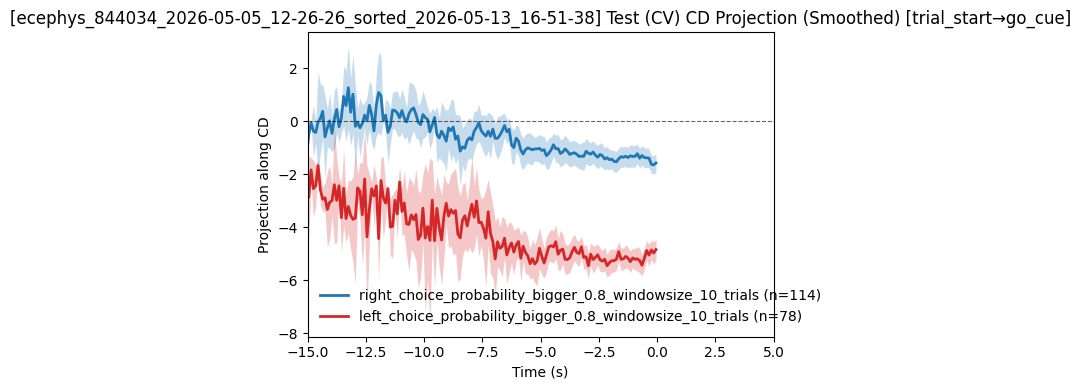

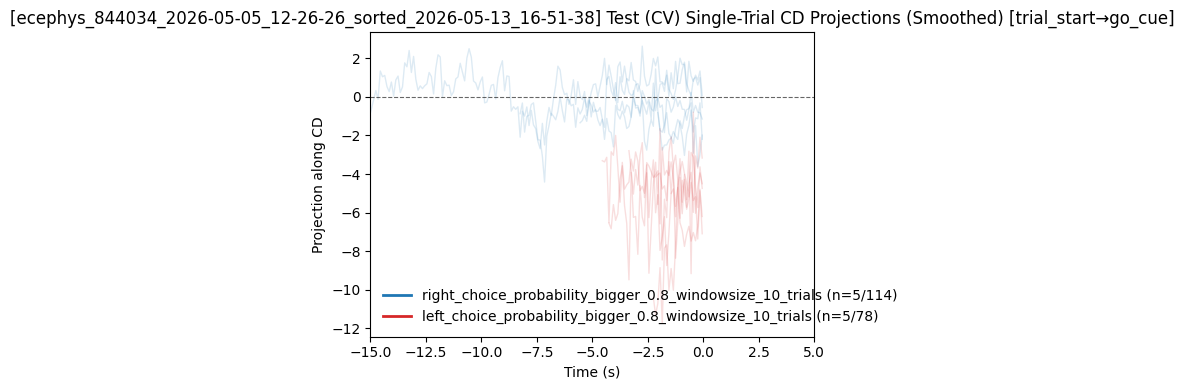

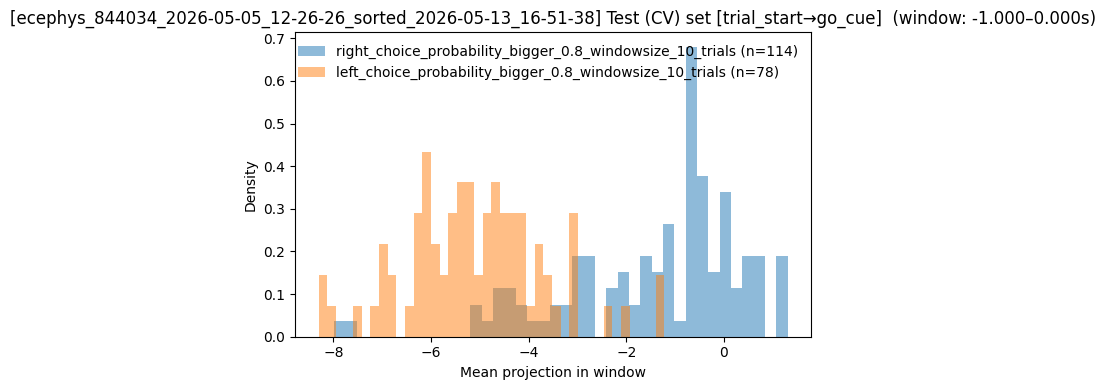


=== Session: ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35 ===
File: CD_ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


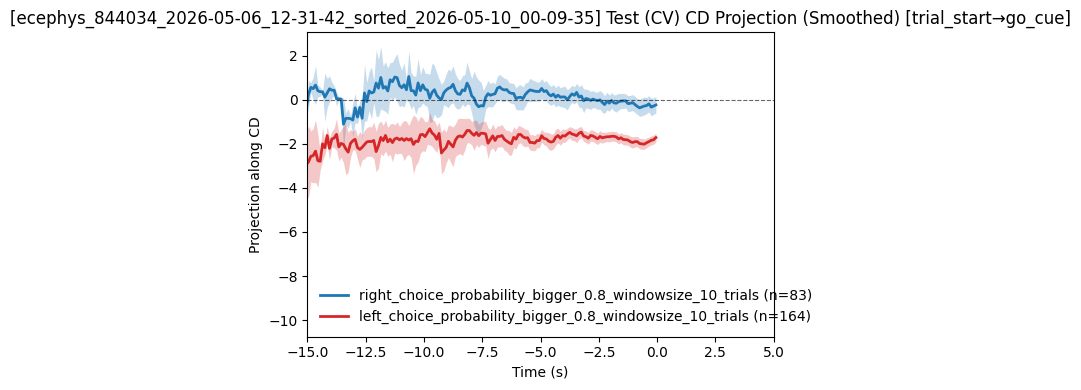

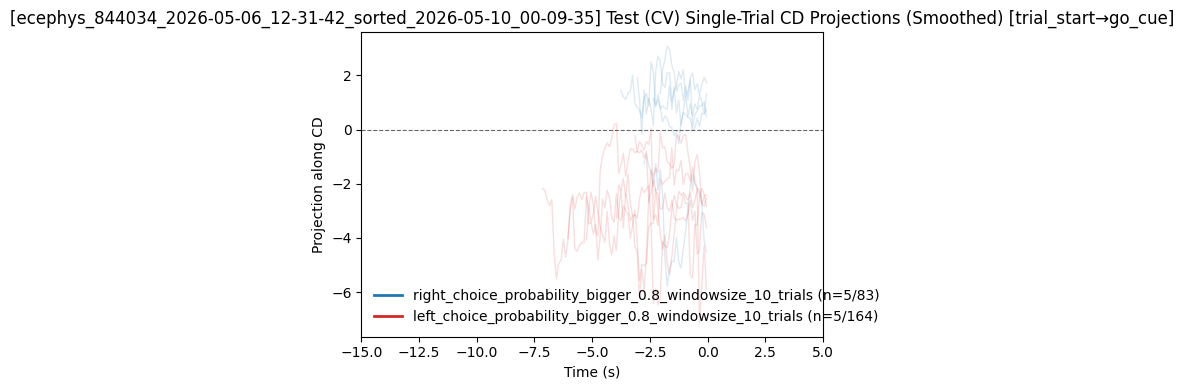

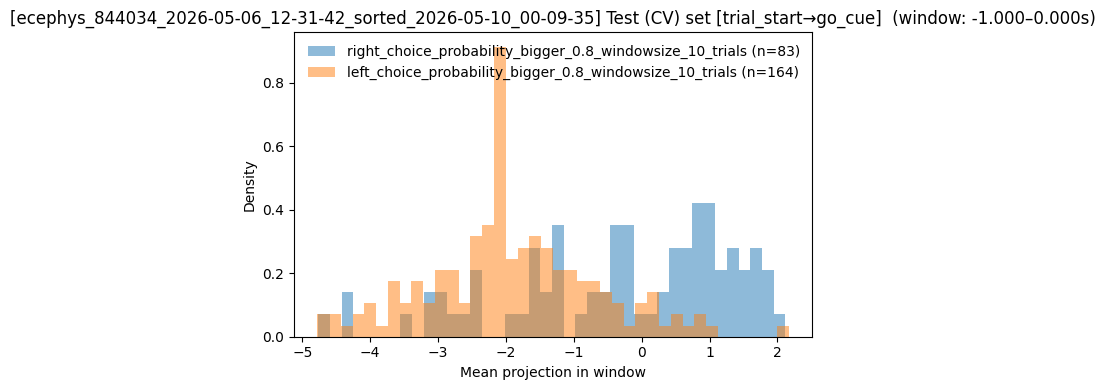


=== Session: ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43 ===
File: CD_ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


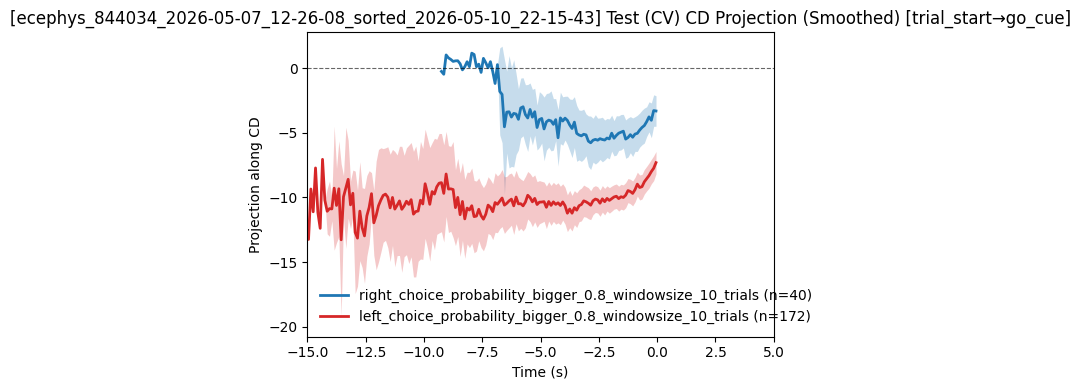

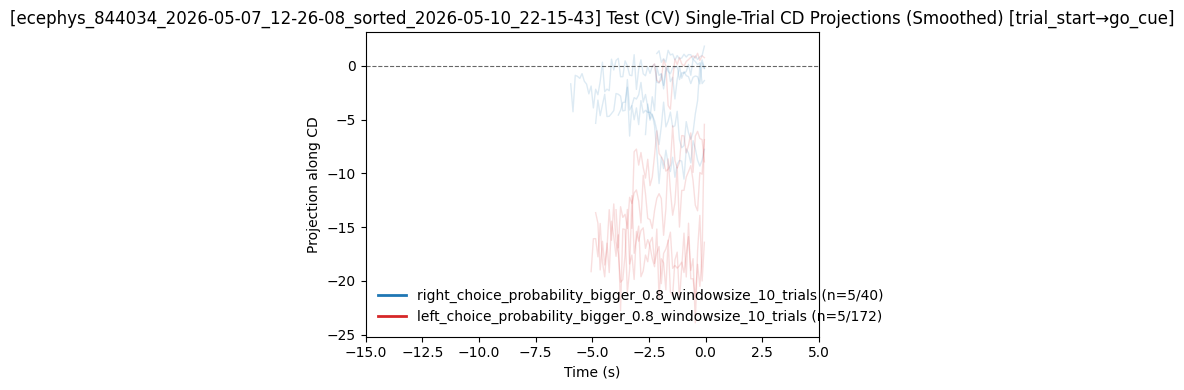

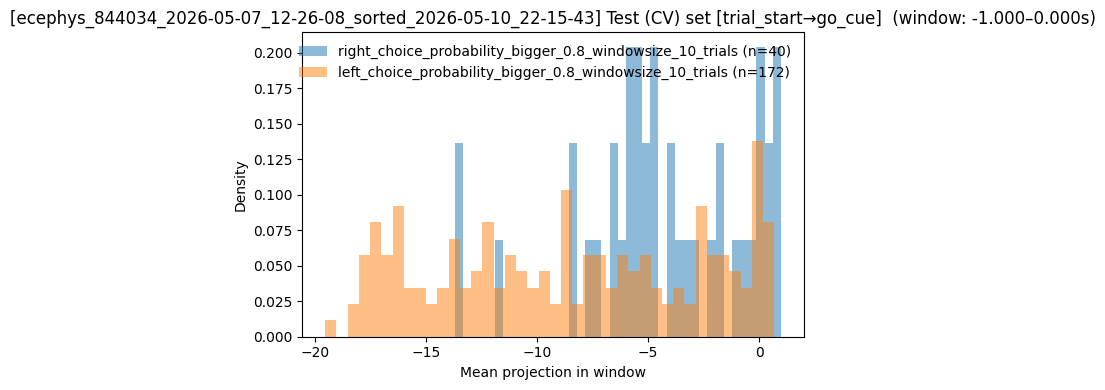


=== Session: ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45 ===
File: CD_ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


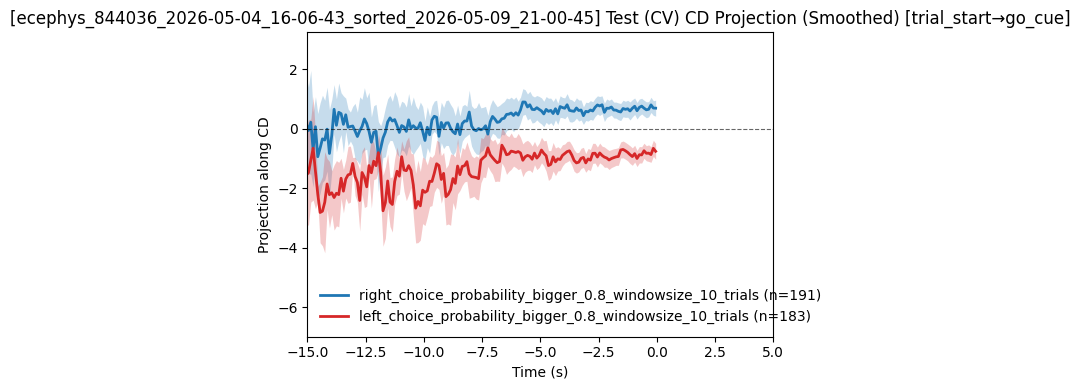

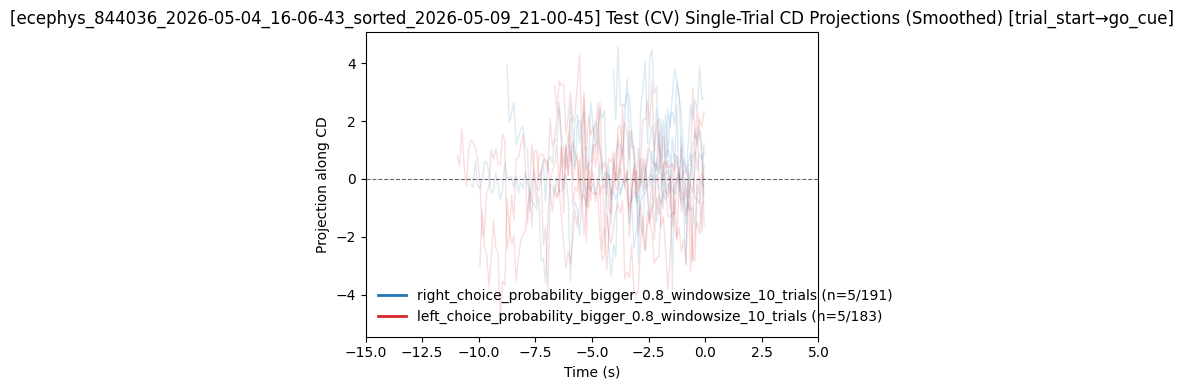

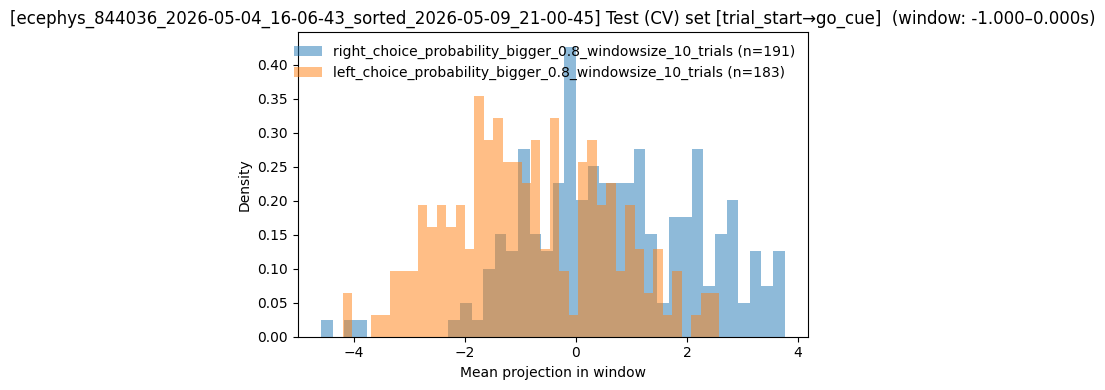


=== Session: ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51 ===
File: CD_ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


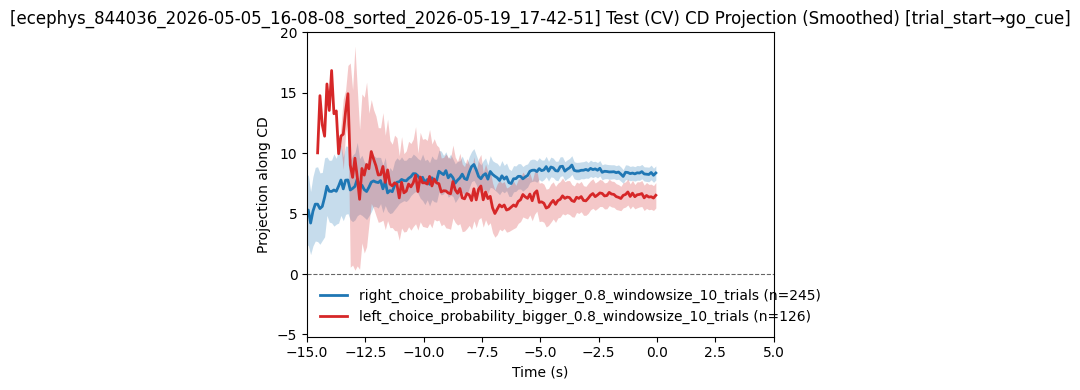

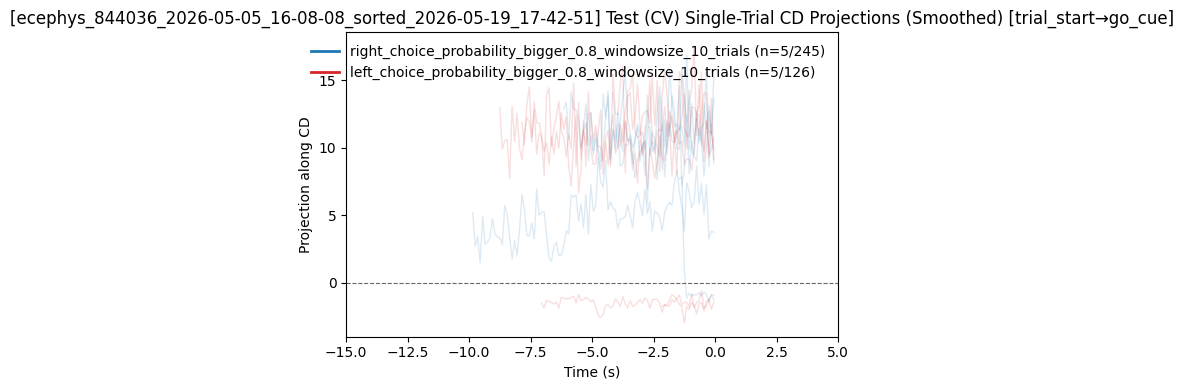

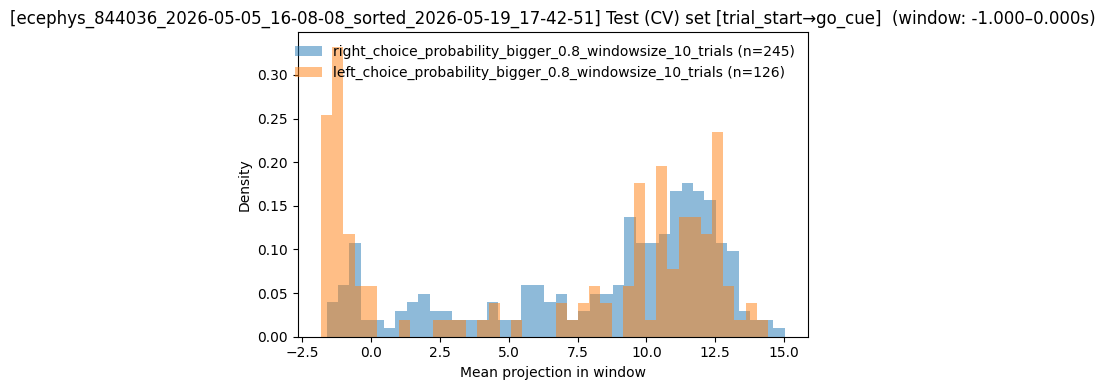


=== Session: ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13 ===
File: CD_ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


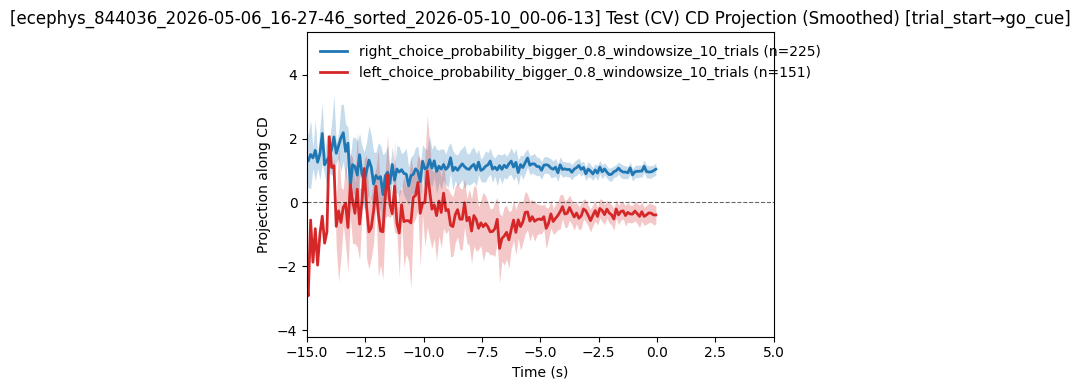

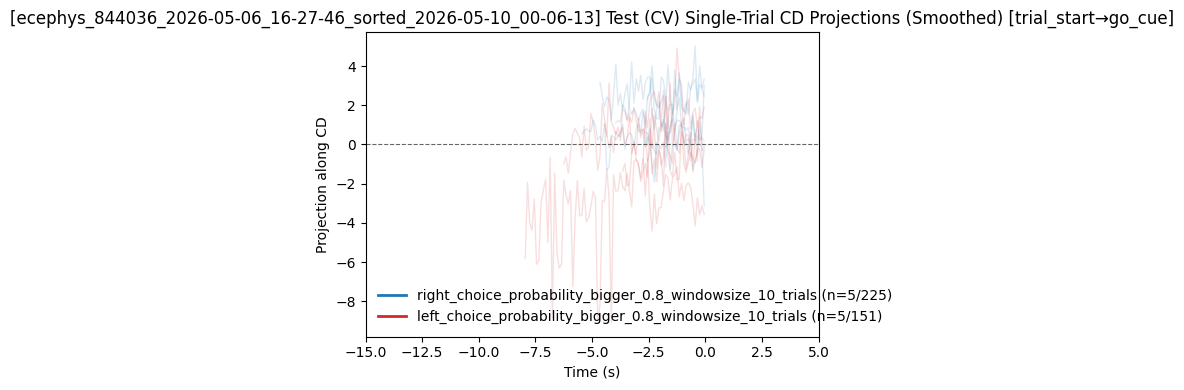

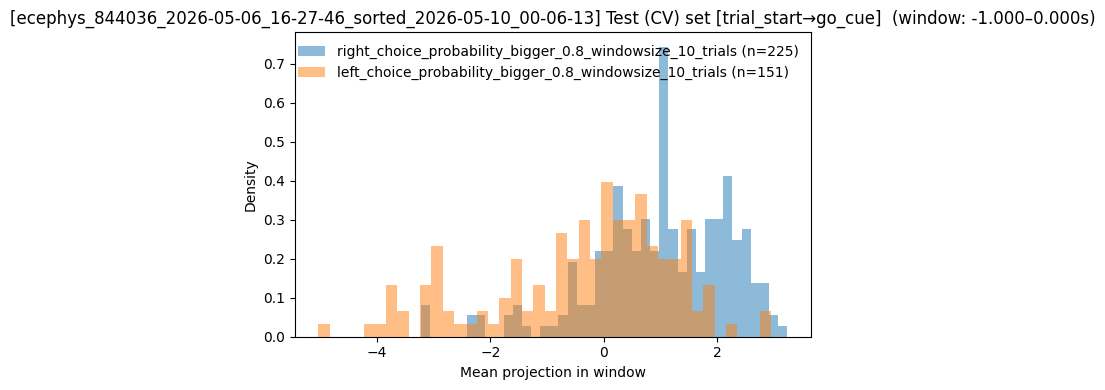

In [31]:
import os
from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path, load_cd_session, plot_cd_session, region_label,
)

viz_region_group     = []
viz_time_window      = (-1, 0)
distribution_window  = (-1, 0)
restrict_events      = ("trial_start", "go_cue")

region_lbl, region_print = region_label(viz_region_group)
print(f"Context CD | region={region_lbl} ({region_print}) | TW={viz_time_window} | align={align}")

for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, context_trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists():
        print(f"[skip] CD zarr not found: {zpath}")
        continue
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session}")
        continue

    print(f"\n=== Session: {session} ===\nFile: {zpath.name}")
    sess = load_cd_session(zpath, beh_csv)
    plot_cd_session(
        sess,
        distribution_window=distribution_window,
        restrict_events=restrict_events,
        restrict_align=align,
        xlim=(-15, 5),
        split="test",
        smooth_gauss=0.0,
        smooth_moving_window=10,
        plot_single_trial=True,
        random_sample_trial_N=5,
    )

## Compare context-CD to choice-CD

Project trials defined by the **current-trial choice** (right_choice vs left_choice) onto the context CD axis. If the two axes overlap, the population is encoding choice rather than context; if context separates classes that choice does not (or vice versa), the dimensions are at least partially distinct.


=== ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38: context-CD projected onto choice classes ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


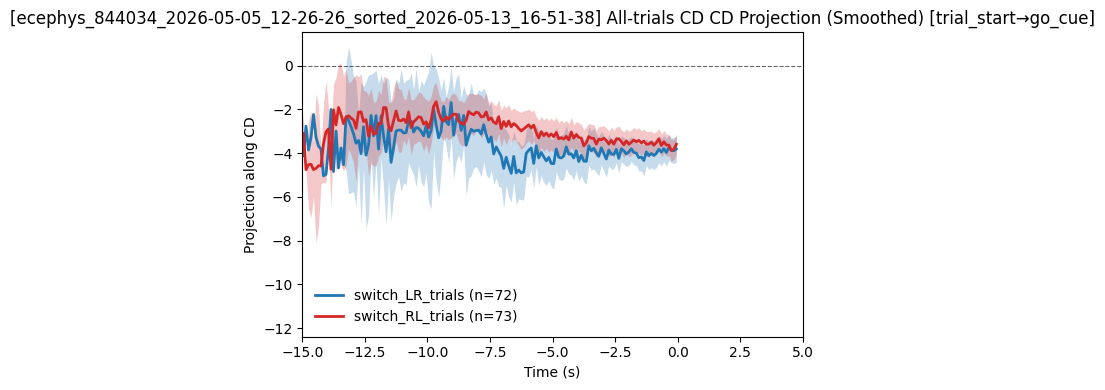

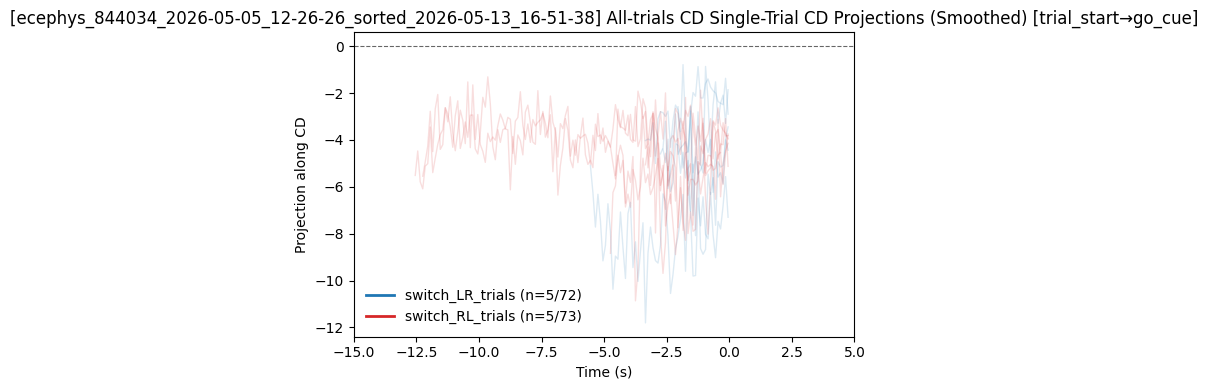

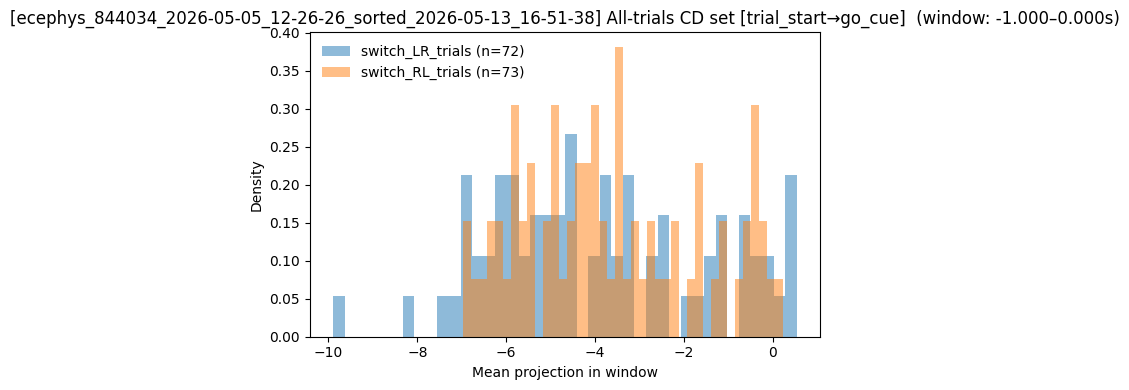


=== ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35: context-CD projected onto choice classes ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


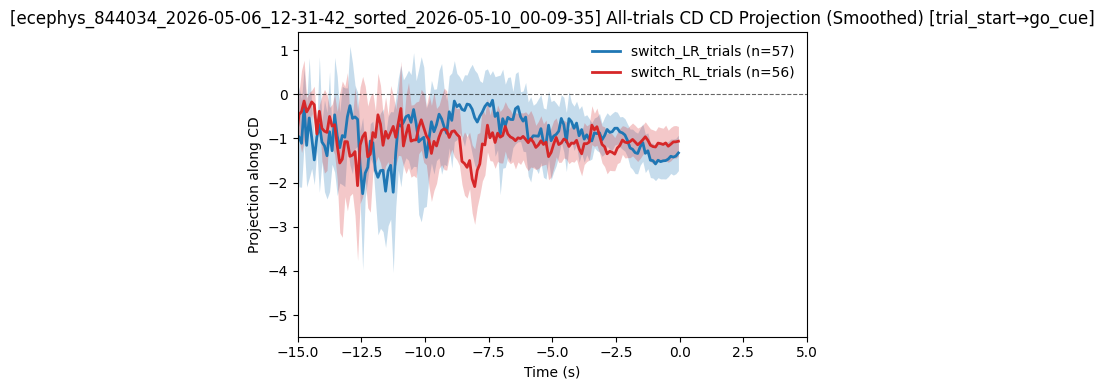

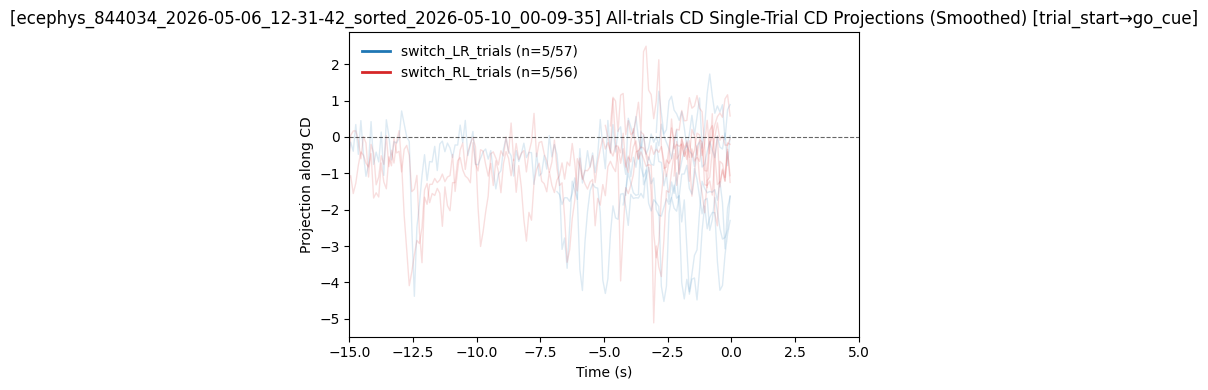

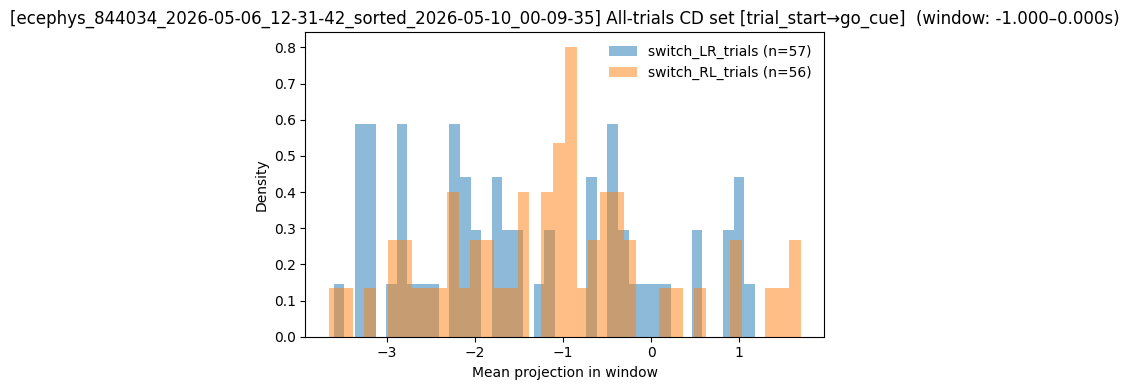


=== ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43: context-CD projected onto choice classes ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


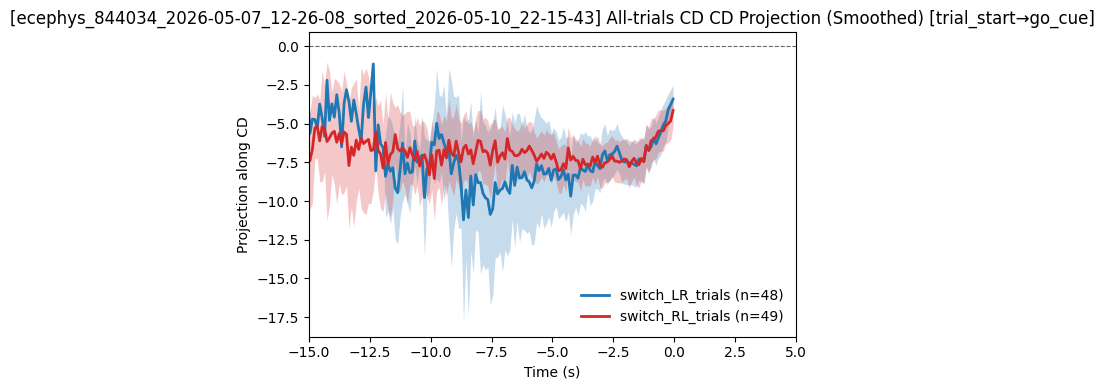

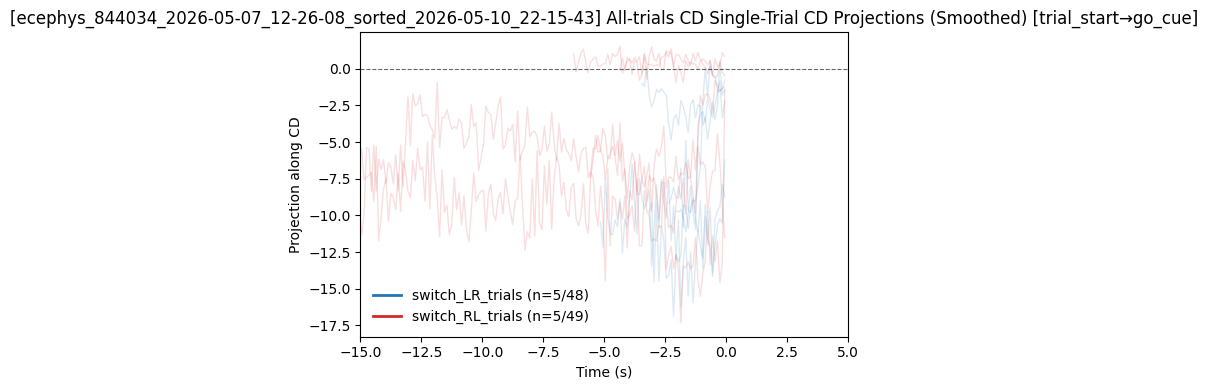

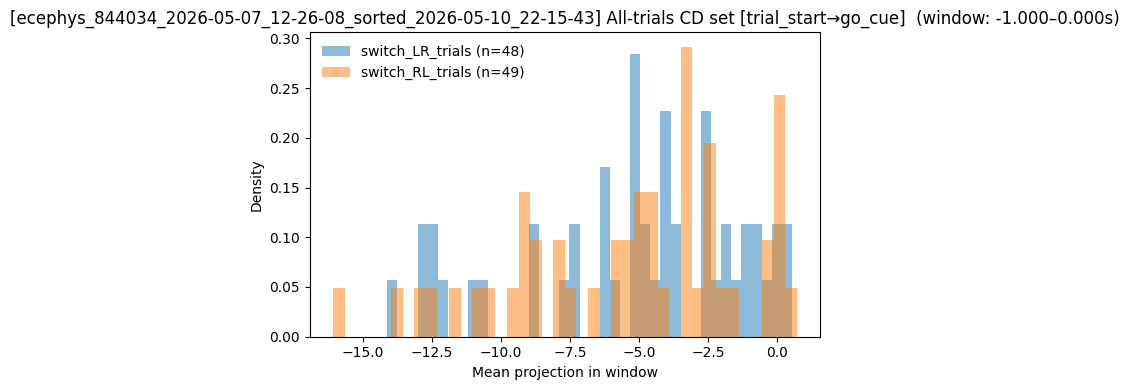


=== ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45: context-CD projected onto choice classes ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


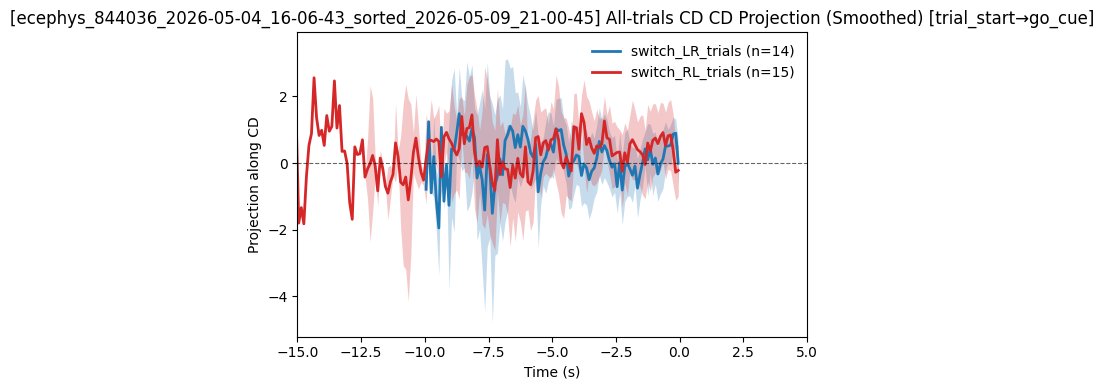

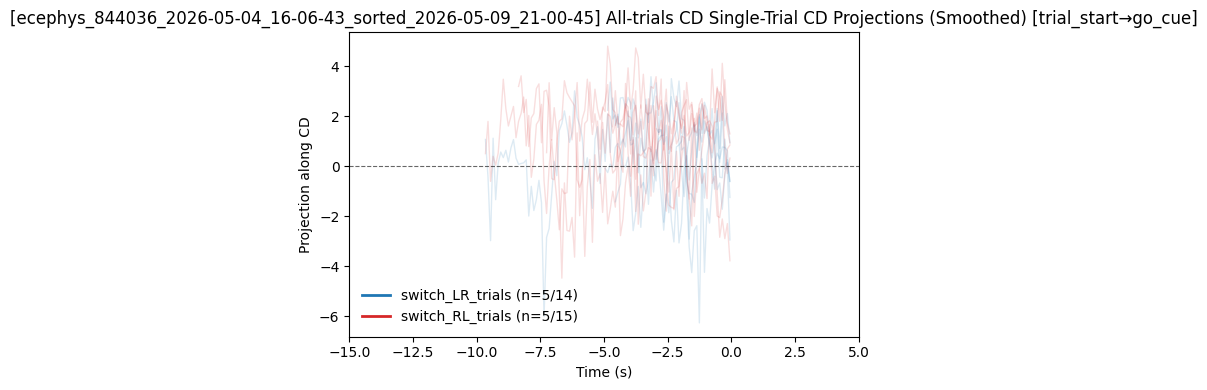

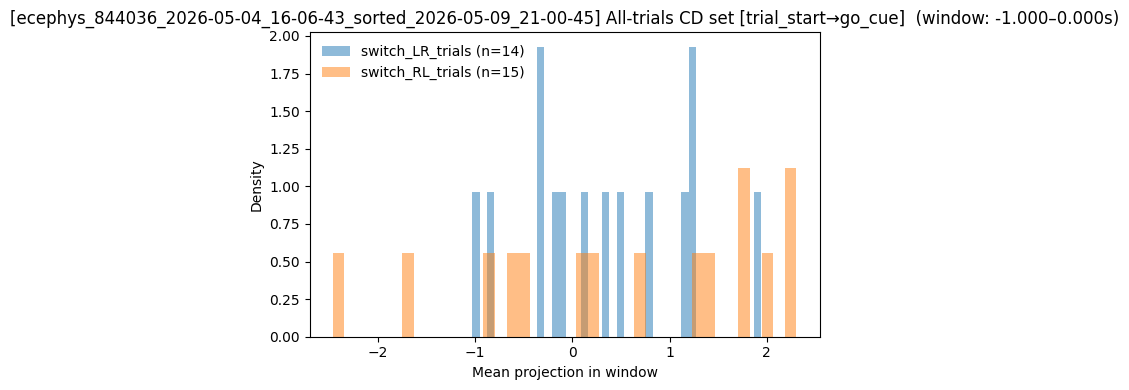


=== ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51: context-CD projected onto choice classes ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


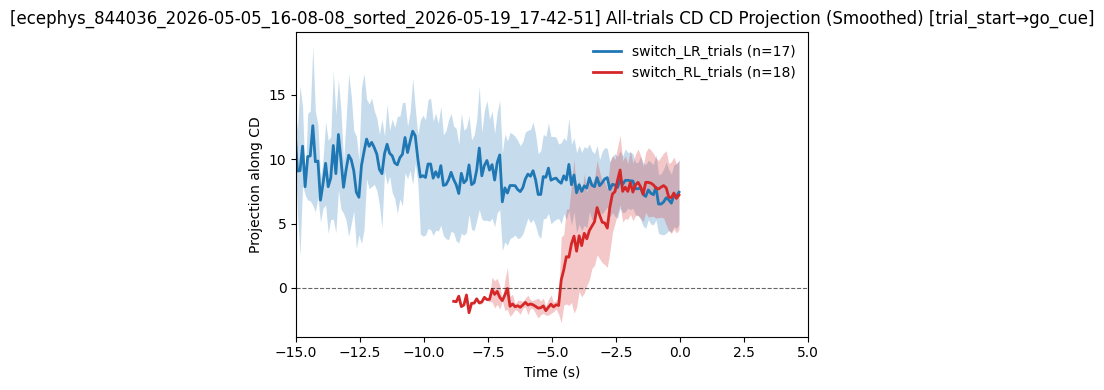

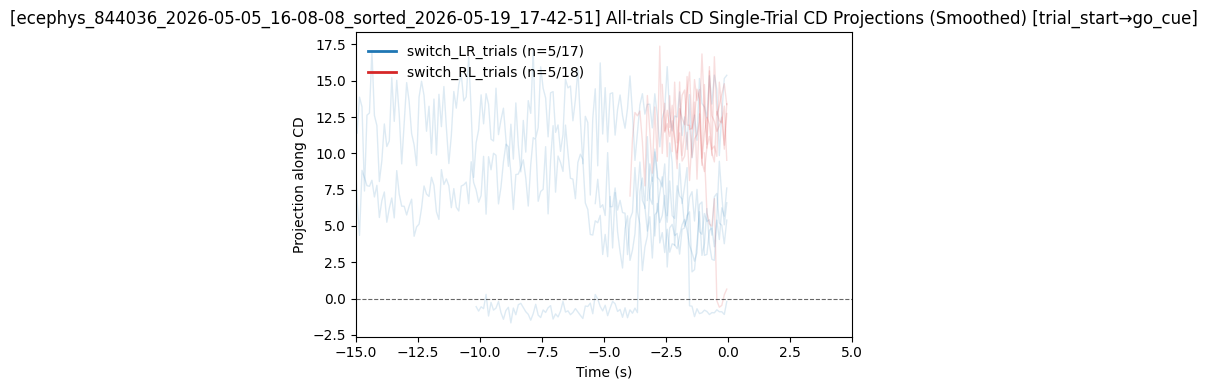

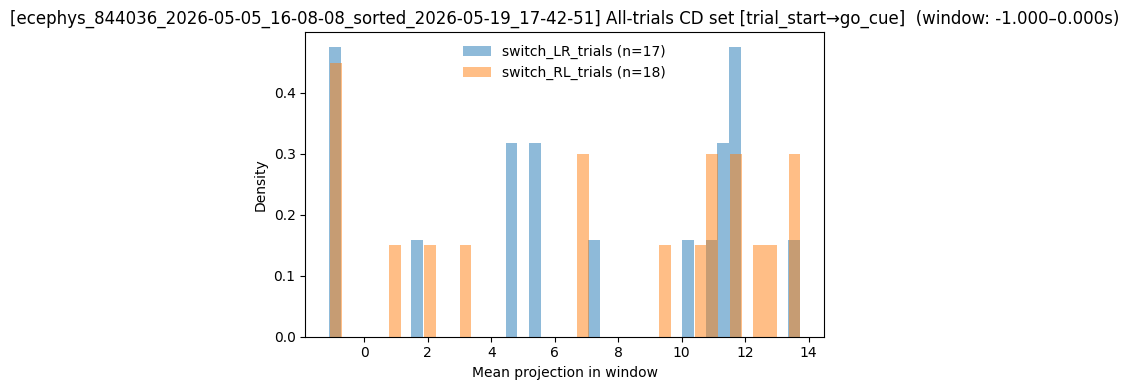


=== ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13: context-CD projected onto choice classes ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


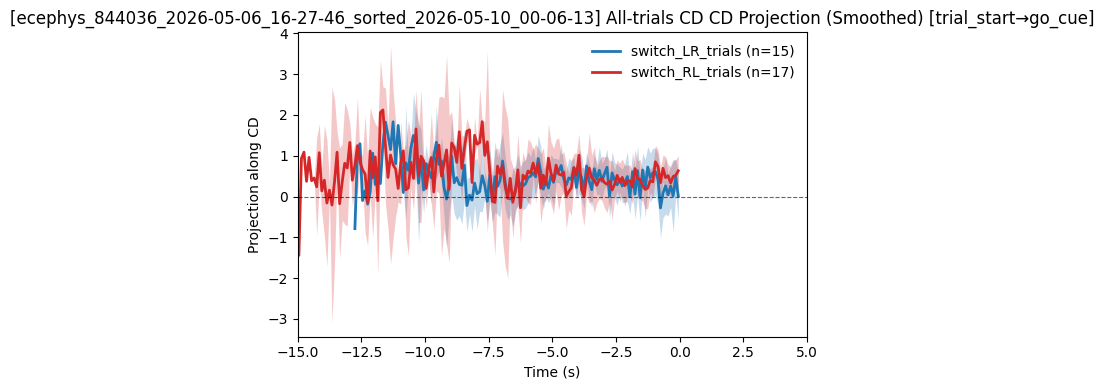

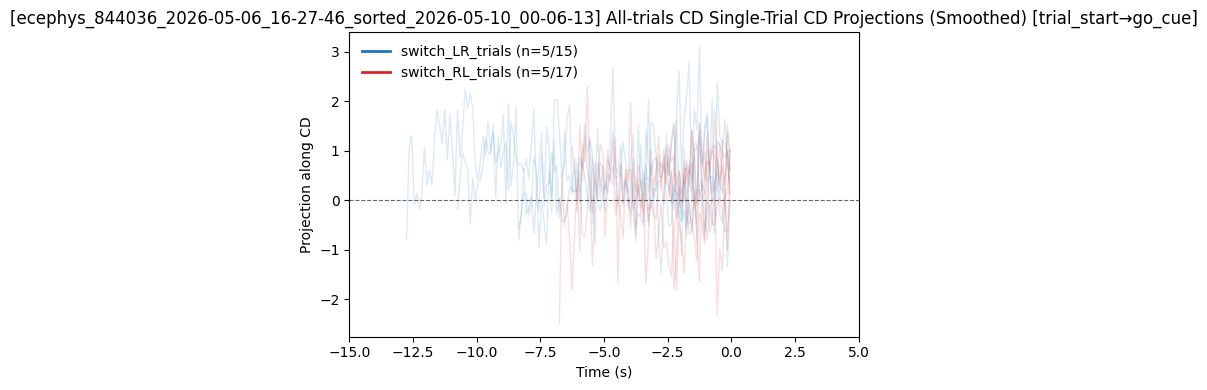

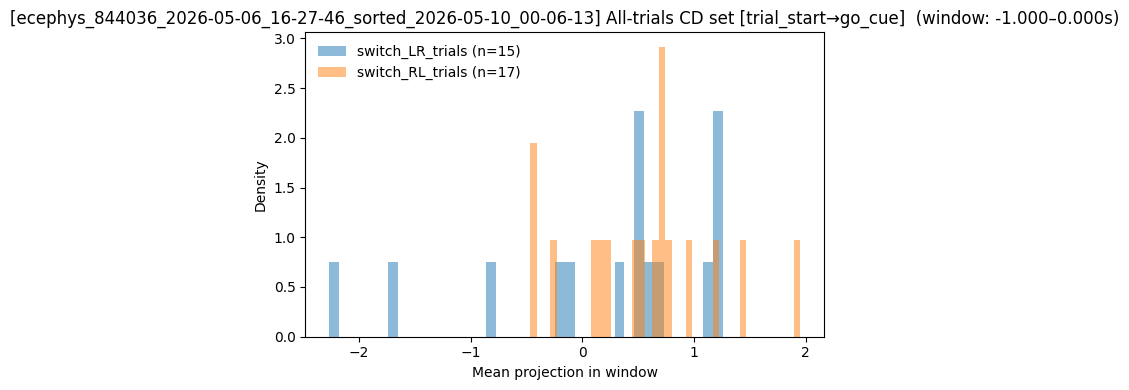

In [32]:
for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, context_trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists() or not os.path.exists(beh_csv):
        continue
    sess = load_cd_session(zpath, beh_csv)
    print(f"\n=== {session}: context-CD projected onto choice classes ===")
    plot_cd_session(
        sess,
        distribution_window=distribution_window,
        restrict_events=restrict_events,
        restrict_align=align,
        xlim=(-15, 5),
        split="test",
        smooth_gauss=0.0,
        smooth_moving_window=5,
        plot_single_trial=True,
        random_sample_trial_N=5,
        #trial_types=["right_choice_trials", "left_choice_trials"],
        trial_types=["switch_LR_trials", "switch_RL_trials"],
    )

## Scatter: average CD projection vs P(right)

Each dot is a trial; x = sliding-window P(right) on that trial, y = mean CD projection over `scatter_window`. Highlighted trial types (e.g. `switch_LR_trials`, `switch_RL_trials`) are overlaid with distinct colors so structure tied to specific behavior categories stands out.

Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Su

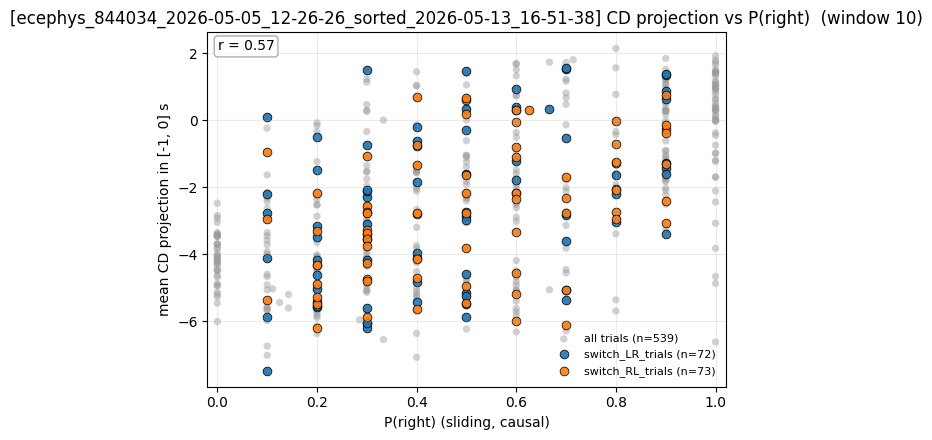

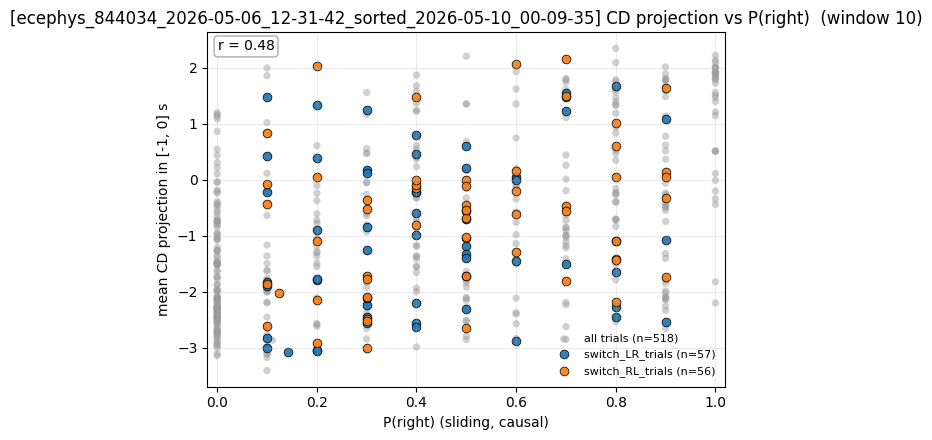

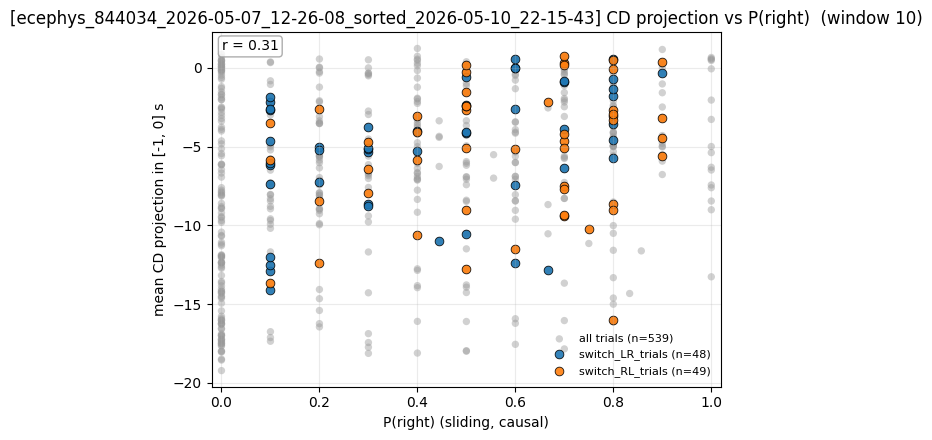

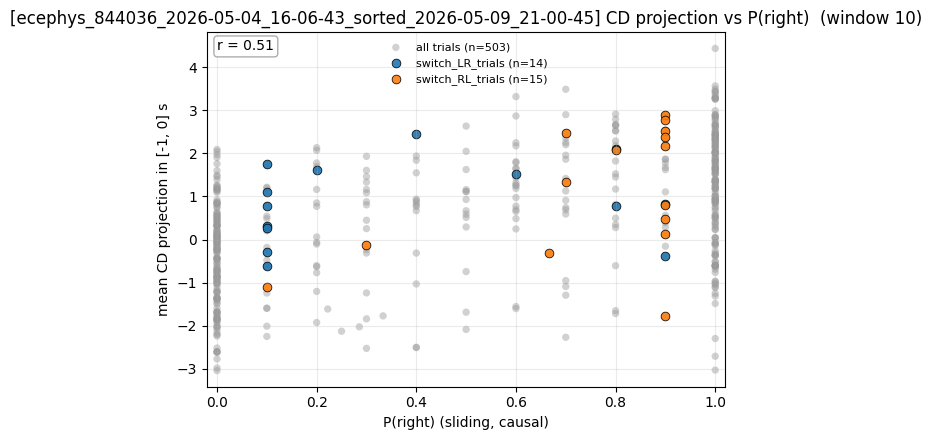

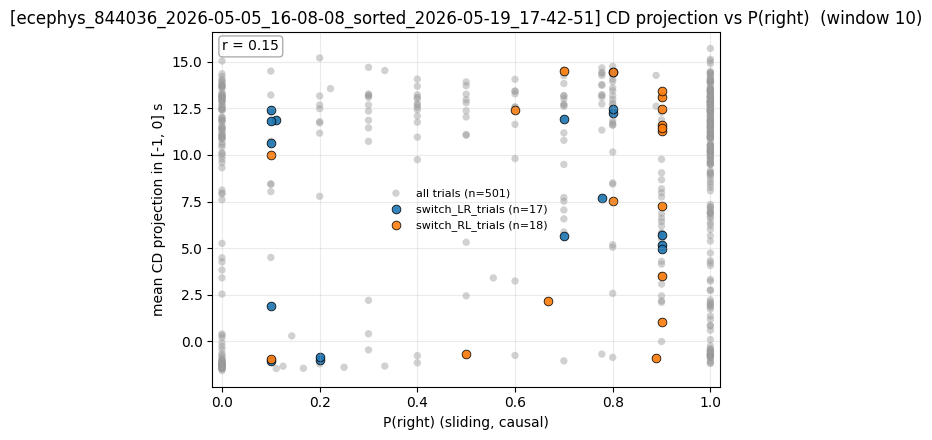

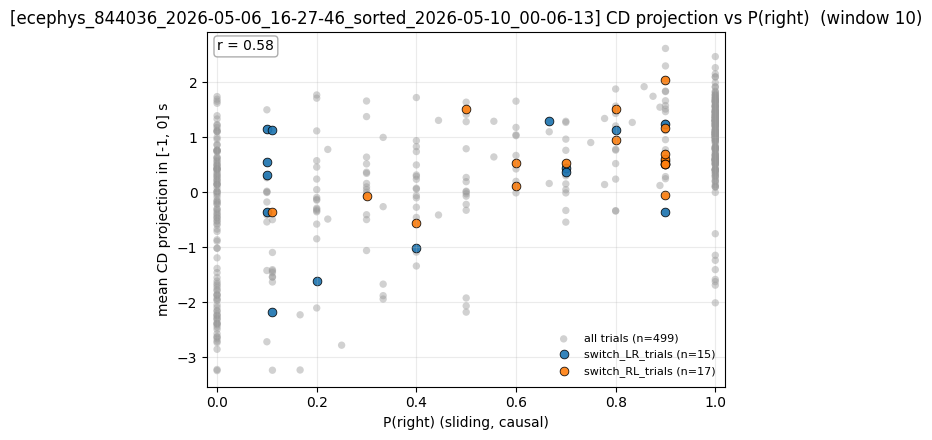

In [17]:
from ephys_dimension_reduction_CD_pipeline import (
    plot_cd_projection_vs_choice_probability,
)

scatter_window  = (-1.0, 0.0)   # window (s) over which to average projection
p_right_window  = 10            # sliding-window length for P(right)
highlight_types = (
    "switch_LR_trials",
    "switch_RL_trials",
)

for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, context_trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists() or not os.path.exists(beh_csv):
        continue
    sess = load_cd_session(zpath, beh_csv)
    plot_cd_projection_vs_choice_probability(
        sess,
        window=scatter_window,
        p_right_window=p_right_window,
        highlight_trial_types=highlight_types,
        restrict_events=restrict_events,
        restrict_align=align,
    )

## Box plot: CD projection grouped by P(right)

Same data as the scatter, but trials are grouped by their P(right) bin and shown as box plots. The connecting line tracks the per-bin median across the P(right) axis.

Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_pipeline.py:1771: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_pipeline.py:1771: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_pipeline.py:1771: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


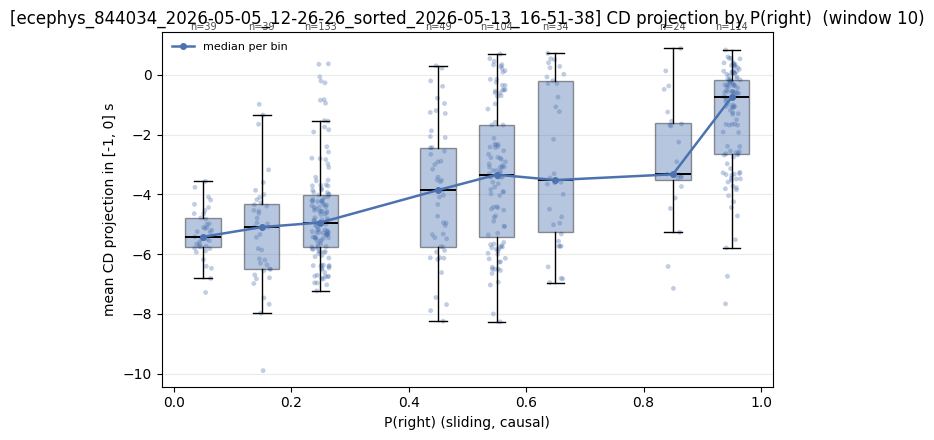

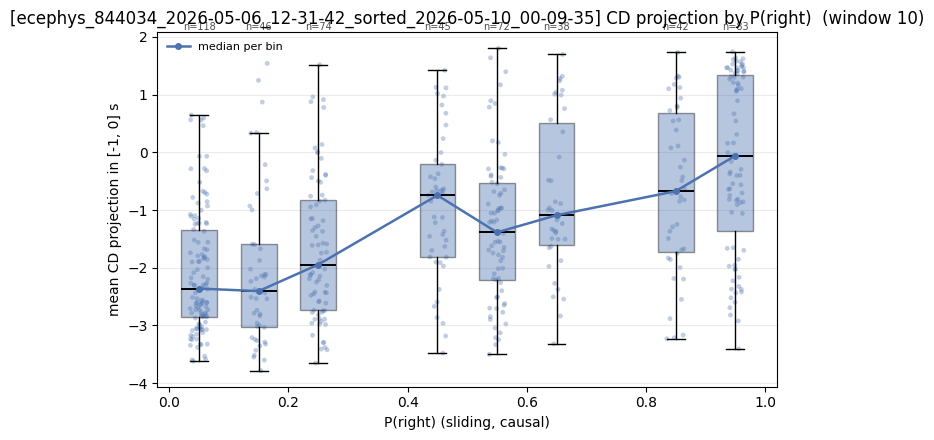

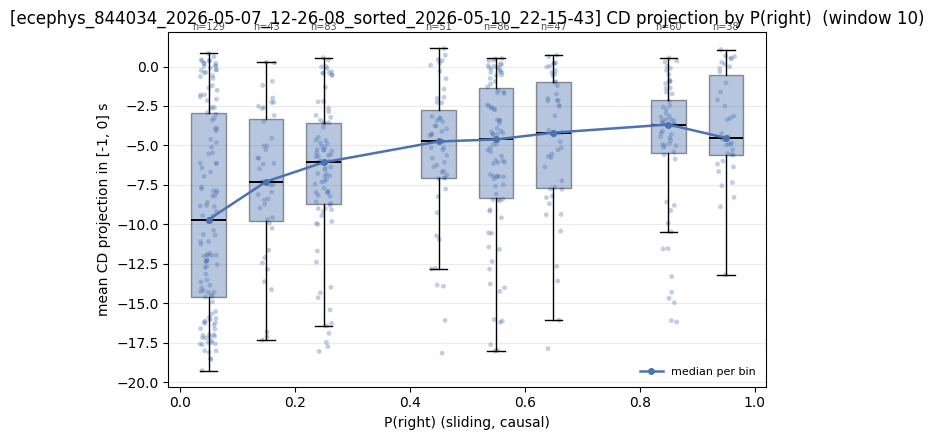

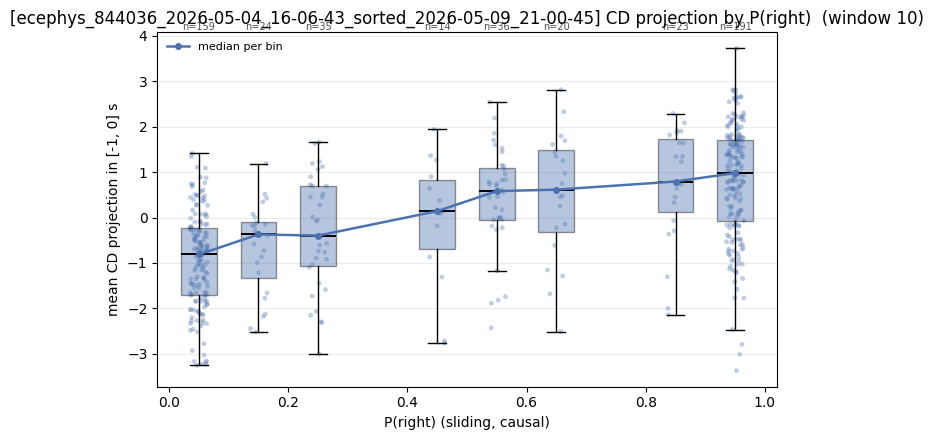

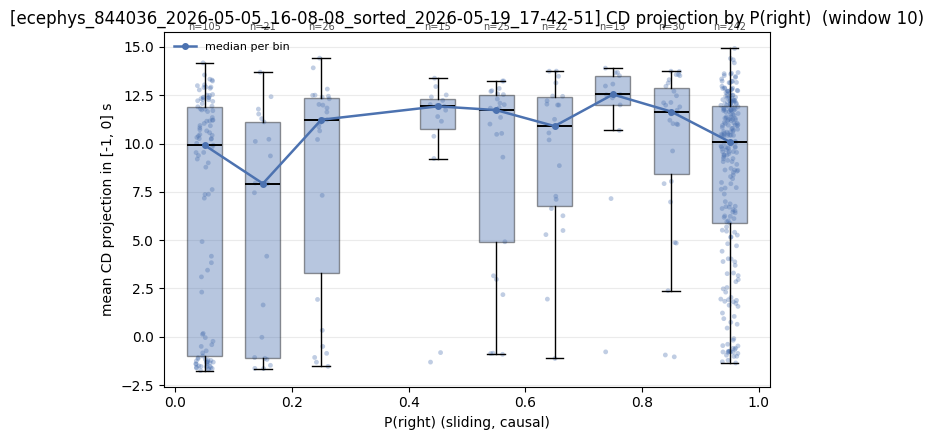

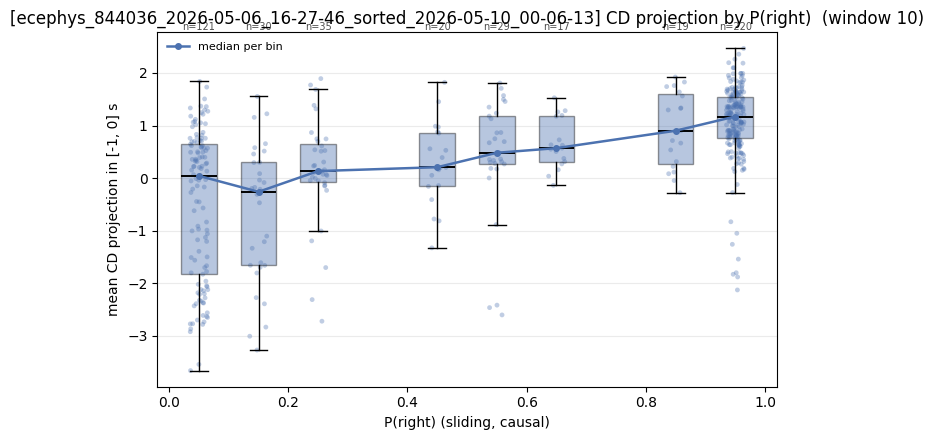

In [34]:
from ephys_dimension_reduction_CD_pipeline import (
    plot_cd_projection_box_by_choice_probability,
)
import numpy as np

highlight_types=[
    "switch_LR_trials",
    "switch_RL_trials"]

    
for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, context_trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists() or not os.path.exists(beh_csv):
        continue
    sess = load_cd_session(zpath, beh_csv)
    plot_cd_projection_box_by_choice_probability(
        sess,
        window=scatter_window,
        p_right_window=p_right_window,
        bins=np.linspace(0, 1, 11),  # uncomment for fixed-edge bins
        min_count=10,
        connect="median",
        show_scatter=True,
        #highlight_trial_types=highlight_types,
        restrict_events=restrict_events,
        restrict_align=align,
    )